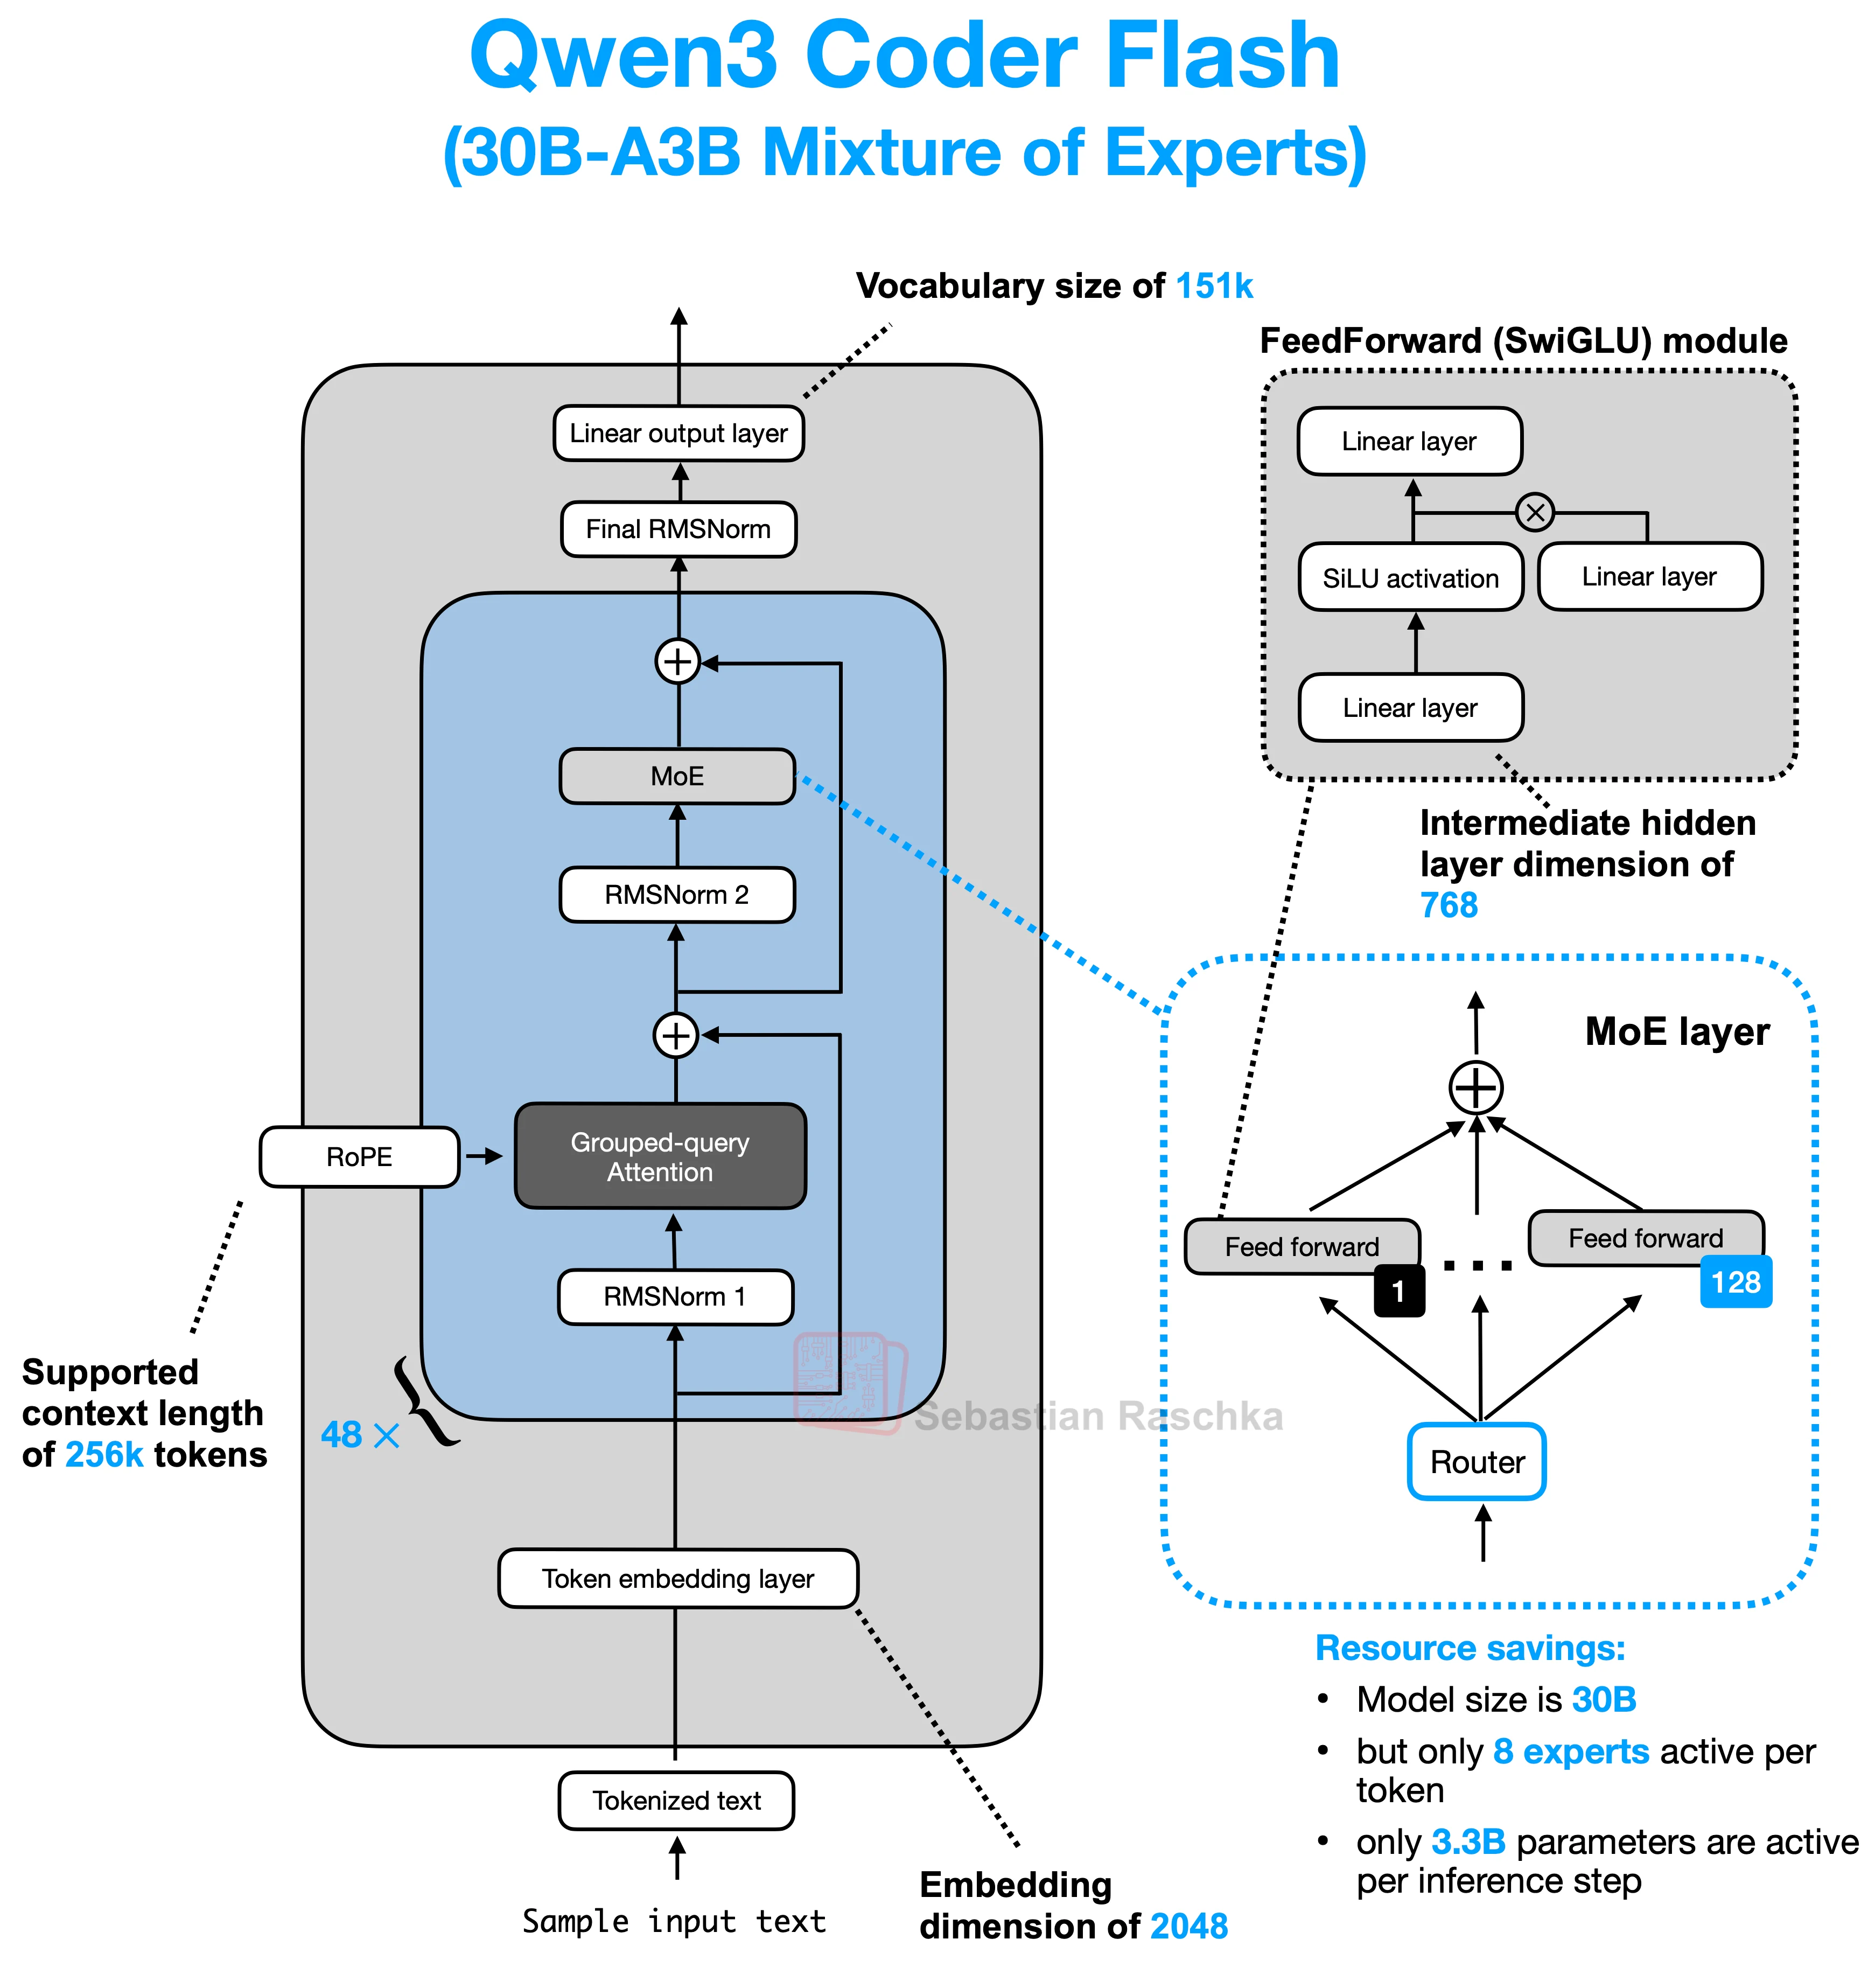

In [26]:
!pip install -q blobfile>=3.0.0 huggingface_hub>=0.24.7 ipywidgets>=8.1.2 safetensors>=0.4.4 sentencepiece>=0.1.99 tokenizers


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn

QWEN3_CONFIG = {
    "vocab_size": 151_936,
    "context_length": 262_144,
    "emb_dim": 2048,
    "n_heads": 32,
    "n_layers": 48,
    "head_dim": 128,
    "qk_norm": True,
    "n_kv_groups": 4,
    "rope_base": 10_000_000.0,
    "dtype": torch.bfloat16,
    "num_experts": 128,
    "num_experts_per_tok": 8,
    "moe_hidden_dim": 768,
    "hidden_dim":768
}

In [3]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg['emb_dim'], cfg['hidden_dim'], dtype=cfg['dtype'], bias=False)
        self.fc2 = nn.Linear(cfg['emb_dim'], cfg['hidden_dim'], dtype=cfg['dtype'], bias=False)
        self.fc3 = nn.Linear(cfg['hidden_dim'], cfg['emb_dim'], dtype=cfg['dtype'], bias=False)

    def forward(self, x):
        x_fc1 = self.fc1(x)
        x_fc2 = self.fc2(x)
        x = nn.functional.silu(x_fc1) * x_fc2
        return self.fc3(x)

In [4]:
class MoEFeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.num_experts_per_tok = cfg['num_experts_per_tok']
        self.num_experts = cfg['num_experts']
        self.emb_dim = cfg['emb_dim']
        self.moe_hidden_dim = cfg["moe_hidden_dim"]

        self.gate = nn.Linear(self.emb_dim, self.num_experts, bias=False, dtype=cfg['dtype'])

        self.fc1 = nn.ModuleList([nn.Linear(self.emb_dim, self.moe_hidden_dim, bias=False, dtype=cfg['dtype'])
                                  for _ in range(self.num_experts)])
        self.fc2 = nn.ModuleList([nn.Linear(self.emb_dim, self.moe_hidden_dim, bias=False, dtype=cfg['dtype'])
                                  for _ in range(self.num_experts)])
        self.fc3 = nn.ModuleList([nn.Linear(self.moe_hidden_dim, self.emb_dim, bias=False, dtype=cfg['dtype'])
                                  for _ in range(self.num_experts)])

    def forward(self, x):
        scores = self.gate(x)
        topk_scores, topk_indices = torch.topk(scores, self.num_experts_per_tok, dim=-1)
        topk_probs = torch.softmax(topk_scores, dim=-1)

        batch, seq_len, _ = x.shape
        x_flat = x.reshape(batch * seq_len, -1)
        out_flat = torch.zeros(batch * seq_len, self.emb_dim, device=x.device, dtype=x.dtype)

        topk_indices_flat = topk_indices.reshape(-1, self.num_experts_per_tok)
        topk_probs_flat = topk_probs.reshape(-1, self.num_experts_per_tok)

        unique_experts = torch.unique(topk_indices_flat)

        for expert_id_tensor in unique_experts:
            expert_id = int(expert_id_tensor.item())
            mask = topk_indices_flat == expert_id
            if not mask.any():
                continue

            token_mask = mask.any(dim=-1)
            selected_idx = token_mask.nonzero(as_tuple=False).squeeze(-1)
            if selected_idx.numel() == 0:
                continue

            expert_input = x_flat.index_select(0, selected_idx)
            hidden = nn.functional.silu(self.fc1[expert_id](expert_input)) * self.fc2[expert_id](expert_input)
            expert_out = self.fc3[expert_id](hidden)

            mask_selected = mask[selected_idx]
            slot_indices = mask_selected.int().argmax(dim=-1, keepdim=True)
            selected_probs = torch.gather(topk_probs_flat.index_select(0, selected_idx), dim=-1, index=slot_indices).squeeze(-1)

            out_flat.index_add_(0, selected_idx, expert_out * selected_probs.unsqueeze(-1))

        return out_flat.reshape(batch, seq_len, self.emb_dim)

In [5]:
class RMSNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-6, bias=False):
        super().__init__()
        self.eps = eps
        self.emb_dim = emb_dim
        self.scale = nn.Parameter(torch.ones(self.emb_dim))
        self.shift = nn.Parameter(torch.zeros(self.emb_dim)) if bias else None

    def forward(self, x):
        input_dtype = x.dtype

        ### Calculating squares and variances can result in really large or really
        ### small numbers. Doing this math in low-precision bfloat16 can cause catastrophic
        ### rounding errors or numerical overflow. Upgrading to float32 ensures the math is perfectly accurate
        x = x.to(torch.float32)

        variance = x.pow(2).mean(dim=-1, keepdim=True)
        norm_x = x * torch.rsqrt(variance + self.eps)
        norm_x = norm_x * self.scale

        if self.shift is not None:
            norm_x = norm_x + self.shift

        return norm_x.to(input_dtype)

In [6]:
def compute_rope_param(head_dim, theta_base=10_000, context_length=4096, dtype=torch.float32):
    assert head_dim % 2 == 0, "head_dim must be divisible by 2 for RoPE"

    ## computing inverse frequencies
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2, dtype=dtype)[: (head_dim // 2)].float() / head_dim))

    ## generate position indices
    positions = torch.arange(context_length, dtype=dtype)

    ## compute the angles
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)

    ## Expand angles to match the head_dim
    angles = torch.cat([angles, angles], dim=1)

    sin = torch.sin(angles)
    cos = torch.cos(angles)

    return sin, cos

def apply_rope(x, sin, cos, offset=0):
    ## x: (batch_size, num_heads, seq_len, head_dim)
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"

    x1 = x[..., : head_dim // 2]  ## first half
    x2 = x[..., head_dim // 2: ]  ## second half

    ## adjust sin and cos shapes
    cos = cos[offset: offset + seq_len, :].unsqueeze(0).unsqueeze(0)    ## Shape: (1, 1, seq_len, head_dim)
    sin = sin[offset: offset + seq_len, :].unsqueeze(0).unsqueeze(0)    ## Shape: (1, 1, seq_len, head_dim)

    ## Apply the rotary transformation
    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x * cos) + (rotated * sin)

    return x_rotated.to(x.dtype)

In [7]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_in, num_heads, num_kv_groups, head_dim=None, qk_norm=False, dtype=None):
        super().__init__()
        assert num_heads % num_kv_groups == 0, "num_heads must be divisible by num_kv_groups"

        self.num_heads = num_heads
        self.num_kv_groups = num_kv_groups
        self.group_size = num_heads // num_kv_groups

        if head_dim is None:
            assert d_in % num_heads == 0, "`d_in` must be divisible by `num_heads` if `head_dim` is not set"
            head_dim = d_in // num_heads

        self.head_dim = head_dim
        self.d_out = num_heads * head_dim

        self.W_query = nn.Linear(d_in, self.d_out, bias=False, dtype=dtype)
        self.W_key = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)

        self.out_proj = nn.Linear(self.d_out, d_in, bias=False, dtype=dtype)

        if qk_norm:
            self.q_norm = RMSNorm(head_dim, eps=1e-6)
            self.k_norm = RMSNorm(head_dim, eps=1e-6)
        else:
            self.q_norm = self.k_norm = None

    def forward(self, x, mask, cos, sin, start_pos=0, cache=None):
        b, num_tokens, _ = x.shape

        ## Apply projections
        queries = self.W_query(x)  # (b, num_tokens, num_heads * head_dim)
        keys = self.W_key(x)       # (b, num_tokens, num_kv_groups * head_dim)
        values = self.W_value(x)   # (b, num_tokens, num_kv_groups * head_dim)

        ## Reshape
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys_new = keys.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)
        values_new = values.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)

        if self.q_norm:
            queries = self.q_norm(queries)
        if self.k_norm:
            keys_new = self.k_norm(keys_new)

        ## Apply RoPE
        queries = apply_rope(queries, cos, sin, offset=start_pos)
        keys_new = apply_rope(keys_new, cos, sin, offset=start_pos)

        if cache is not None:
            prev_k, prev_v = cache
            keys = torch.cat([prev_k, keys_new], dim=2)
            values = torch.cat([prev_v, values_new], dim=2)
            next_cache = (keys, values)
        else:
            start_pos = 0  ## reset rope
            keys, values = keys_new, values_new
            next_cache = (keys, values)

        ## Expand K and V to match number of heads
        keys = keys.repeat_interleave(self.group_size, dim=1)
        values = values.repeat_interleave(self.group_size, dim=1)

        attn_scores = queries @ keys.transpose(-1, -2)
        attn_scores = attn_scores.masked_fill(mask, -torch.inf)
        attn_weights = torch.softmax(attn_scores / self.head_dim ** 0.5, dim=-1)

        context = (attn_weights @ values).transpose(1, 2).reshape(b, num_tokens, self.d_out)
        return self.out_proj(context), next_cache

In [8]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn = GroupedQueryAttention(
            d_in = cfg['emb_dim'],
            num_heads = cfg['n_heads'],
            head_dim=cfg['head_dim'],
            num_kv_groups=cfg['n_kv_groups'],
            qk_norm=cfg['qk_norm'],
            dtype=cfg['dtype']
        )

        if cfg['num_experts'] > 0:
            self.ff = MoEFeedForward(cfg)
        else:
            self.ff = FeedForward(cfg)

        self.norm1 = RMSNorm(emb_dim=cfg['emb_dim'], eps=1e-6)
        self.norm2 = RMSNorm(emb_dim=cfg['emb_dim'], eps=1e-6)

    def forward(self, x, mask, cos, sin, start_pos=0, cache=None):
        shortcut = x
        x = self.norm1(x)
        x, next_cache = self.attn(x, mask, cos, sin, start_pos, cache)
        x = shortcut + x

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = shortcut + x

        return x, next_cache

In [9]:
class Qwen3Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"], dtype=cfg["dtype"])

        self.trf_blocks = nn.ModuleList(
            [TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = RMSNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False, dtype=cfg["dtype"])

        if cfg["head_dim"] is None:
            head_dim = cfg["emb_dim"] // cfg["n_heads"]
        else:
            head_dim = cfg["head_dim"]
        cos, sin = compute_rope_param(
            head_dim=head_dim,
            theta_base=cfg["rope_base"],
            context_length=cfg["context_length"]
        )
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)
        self.cfg = cfg
        self.current_pos = 0  # Track current position in KV cache

    def forward(self, in_idx, cache=None):
        tok_embeds = self.tok_emb(in_idx)
        x = tok_embeds

        num_tokens = x.shape[1]
        if cache is not None:
            pos_start = self.current_pos
            pos_end = pos_start + num_tokens
            self.current_pos = pos_end
            mask = torch.triu(
                torch.ones(pos_end, pos_end, device=x.device, dtype=torch.bool),
                diagonal=1
            )[pos_start:pos_end, :pos_end]
        else:
            pos_start = 0  # Not strictly necessary but helps torch.compile
            mask = torch.triu(
                torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1
            )

        # Shape (1, 1, num_tokens, num_tokens) to broadcast across batch and heads
        mask = mask[None, None, :, :]

        for i, block in enumerate(self.trf_blocks):
            blk_cache = cache.get(i) if cache else None
            x, new_blk_cache = block(x, mask, self.cos, self.sin, pos_start, blk_cache)
            if cache is not None:
                cache.update(i, new_blk_cache)

        x = self.final_norm(x)
        logits = self.out_head(x.to(self.cfg["dtype"]))
        return logits

    def reset_kv_cache(self):
        self.current_pos = 0

In [10]:
class KVCache:
    def __init__(self, n_layers):
        self.cache = [None] * n_layers

    def get(self, layer_idx):
        return self.cache[layer_idx]

    def update(self, layer_idx, value):
        self.cache[layer_idx] = value

    def get_all(self):
        return self.cache

    def reset(self):
        for i in range(len(self.cache)):
            self.cache[i] = None

In [11]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

cuda


In [12]:
torch.manual_seed(123)

with device:
    model = Qwen3Model(QWEN3_CONFIG)

In [13]:
model(torch.tensor([1, 2, 3]).unsqueeze(0).to(device))

tensor([[[-1.1875, -0.3965, -0.8477,  ...,  0.3730,  0.3809,  0.2188],
         [-0.4551,  0.0232,  0.0698,  ...,  0.3027, -0.0698, -0.1426],
         [-1.0078, -0.0371, -0.1045,  ...,  0.0596, -0.2891,  0.3008]]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>)

In [14]:
def model_memory_size(model, input_dtype=torch.float32):
    total_params = 0
    total_grads = 0
    for param in model.parameters():
        # Calculate total number of elements per parameter
        param_size = param.numel()
        total_params += param_size
        # Check if gradients are stored for this parameter
        if param.requires_grad:
            total_grads += param_size

    # Calculate buffer size (non-parameters that require memory)
    total_buffers = sum(buf.numel() for buf in model.buffers())

    # Size in bytes = (Number of elements) * (Size of each element in bytes)
    # We assume parameters and gradients are stored in the same type as input dtype
    element_size = torch.tensor(0, dtype=input_dtype).element_size()
    total_memory_bytes = (total_params + total_grads + total_buffers) * element_size

    # Convert bytes to gigabytes
    total_memory_gb = total_memory_bytes / (1024**3)

    return total_memory_gb

print(f"float32 (PyTorch default): {model_memory_size(model, input_dtype=torch.float32):.2f} GB")
print(f"bfloat16: {model_memory_size(model, input_dtype=torch.bfloat16):.2f} GB")

float32 (PyTorch default): 227.73 GB
bfloat16: 113.87 GB


In [15]:
def load_weights_into_qwen(model, param_config, params):
    def assign(left, right, tensor_name="unknown"):
        if left.shape != right.shape:
            raise ValueError(f"Shape mismatch in tensor '{tensor_name}'. Left: {left.shape}, Right: {right.shape}")

        with torch.no_grad():
            if isinstance(right, torch.Tensor):
                left.copy_(right)
            else:
                left.copy_(torch.as_tensor(right, dtype=left.dtype, device=left.device))

        return left

    model.tok_emb.weight = assign(model.tok_emb.weight, params["model.embed_tokens.weight"], "model.embed_tokens.weight")

    for l in range(param_config["n_layers"]):
        block = model.trf_blocks[l]
        att = block.attn

        # Q, K, V projections
        att.W_query.weight = assign(
            att.W_query.weight,
            params[f"model.layers.{l}.self_attn.q_proj.weight"],
            f"model.layers.{l}.self_attn.q_proj.weight"
        )
        att.W_key.weight = assign(
            att.W_key.weight,
            params[f"model.layers.{l}.self_attn.k_proj.weight"],
            f"model.layers.{l}.self_attn.k_proj.weight"
        )
        att.W_value.weight = assign(
            att.W_value.weight,
            params[f"model.layers.{l}.self_attn.v_proj.weight"],
            f"model.layers.{l}.self_attn.v_proj.weight"
        )

        # Output projection
        att.out_proj.weight = assign(
            att.out_proj.weight,
            params[f"model.layers.{l}.self_attn.o_proj.weight"],
            f"model.layers.{l}.self_attn.o_proj.weight"
        )

        # QK norms
        if hasattr(att, "q_norm") and att.q_norm is not None:
            att.q_norm.scale = assign(
                att.q_norm.scale,
                params[f"model.layers.{l}.self_attn.q_norm.weight"],
                f"model.layers.{l}.self_attn.q_norm.weight"
            )
        if hasattr(att, "k_norm") and att.k_norm is not None:
            att.k_norm.scale = assign(
                att.k_norm.scale,
                params[f"model.layers.{l}.self_attn.k_norm.weight"],
                f"model.layers.{l}.self_attn.k_norm.weight"
            )

        # Attention layernorm
        block.norm1.scale = assign(
            block.norm1.scale,
            params[f"model.layers.{l}.input_layernorm.weight"],
            f"model.layers.{l}.input_layernorm.weight"
        )

        # Feedforward weights
        if "num_experts" in param_config and param_config["num_experts"] > 0:
            # Load router (gating) weights
            block.ff.gate.weight = assign(
                block.ff.gate.weight,
                params[f"model.layers.{l}.mlp.gate.weight"],
                f"model.layers.{l}.mlp.gate.weight"
            )
            # Load expert weights
            for e in range(param_config["num_experts"]):
                prefix = f"model.layers.{l}.mlp.experts.{e}"
                block.ff.fc1[e].weight = assign(
                    block.ff.fc1[e].weight,
                    params[f"{prefix}.gate_proj.weight"],
                    f"{prefix}.gate_proj.weight"
                )
                block.ff.fc2[e].weight = assign(
                    block.ff.fc2[e].weight,
                    params[f"{prefix}.up_proj.weight"],
                    f"{prefix}.up_proj.weight"
                )
                block.ff.fc3[e].weight = assign(
                    block.ff.fc3[e].weight,
                    params[f"{prefix}.down_proj.weight"],
                    f"{prefix}.down_proj.weight"
                )

        else:
            block.ff.fc1.weight = assign(
                block.ff.fc1.weight,
                params[f"model.layers.{l}.mlp.gate_proj.weight"],
                f"model.layers.{l}.mlp.gate_proj.weight"
            )
            block.ff.fc2.weight = assign(
                block.ff.fc2.weight,
                params[f"model.layers.{l}.mlp.up_proj.weight"],
                f"model.layers.{l}.mlp.up_proj.weight"
            )
            block.ff.fc3.weight = assign(
                block.ff.fc3.weight,
                params[f"model.layers.{l}.mlp.down_proj.weight"],
                f"model.layers.{l}.mlp.down_proj.weight"
            )

        block.norm2.scale = assign(
            block.norm2.scale,
            params[f"model.layers.{l}.post_attention_layernorm.weight"],
            f"model.layers.{l}.post_attention_layernorm.weight"
        )

    # Final normalization and output head
    model.final_norm.scale = assign(model.final_norm.scale, params["model.norm.weight"], "model.norm.weight")

    if "lm_head.weight" in params:
        model.out_head.weight = assign(model.out_head.weight, params["lm_head.weight"], "lm_head.weight")
    else:
        model.out_head.weight = model.tok_emb.weight
        print("Model uses weight tying.")

In [16]:
import json
import os
from pathlib import Path
from safetensors.torch import load_file
from huggingface_hub import snapshot_download

repo_id = "Qwen/Qwen3-Coder-30B-A3B-Instruct"  # (Qwen3 Coder Flash)

local_dir = Path(repo_id).parts[-1]

repo_dir = snapshot_download(repo_id=repo_id, local_dir=local_dir)
index_path = os.path.join(repo_dir, "model.safetensors.index.json")
with open(index_path, "r") as f:
    index = json.load(f)

weights_dict = {}
for filename in set(index["weight_map"].values()):
    shard_path = os.path.join(repo_dir, filename)
    shard = load_file(shard_path)
    weights_dict.update(shard)

load_weights_into_qwen(model, QWEN3_CONFIG, weights_dict)
model.to(device)

Fetching 28 files:   0%|          | 0/28 [00:00<?, ?it/s]

Qwen3Model(
  (tok_emb): Embedding(151936, 2048)
  (trf_blocks): ModuleList(
    (0-47): 48 x TransformerBlock(
      (attn): GroupedQueryAttention(
        (W_query): Linear(in_features=2048, out_features=4096, bias=False)
        (W_key): Linear(in_features=2048, out_features=512, bias=False)
        (W_value): Linear(in_features=2048, out_features=512, bias=False)
        (out_proj): Linear(in_features=4096, out_features=2048, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): MoEFeedForward(
        (gate): Linear(in_features=2048, out_features=128, bias=False)
        (fc1): ModuleList(
          (0-127): 128 x Linear(in_features=2048, out_features=768, bias=False)
        )
        (fc2): ModuleList(
          (0-127): 128 x Linear(in_features=2048, out_features=768, bias=False)
        )
        (fc3): ModuleList(
          (0-127): 128 x Linear(in_features=768, out_features=2048, bias=False)
        )
      )
      (norm1): RMSNorm()
      (

In [17]:
import re
from tokenizers import Tokenizer

class Qwen3Tokenizer:
    _SPECIALS = [
        "<|endoftext|>",
        "<|im_start|>", "<|im_end|>",
        "<|object_ref_start|>", "<|object_ref_end|>",
        "<|box_start|>", "<|box_end|>",
        "<|quad_start|>", "<|quad_end|>",
        "<|vision_start|>", "<|vision_end|>",
        "<|vision_pad|>", "<|image_pad|>", "<|video_pad|>",
        "<think>", "</think>"
    ]
    _SPLIT_RE = re.compile(r"(<\|[^>]+?\|>|<think>|</think>)")

    def __init__(self, tokenizer_file_path="tokenizer.json", repo_id=None,
                 apply_chat_template=True, add_generation_prompt=False, add_thinking=False):

        self.apply_chat_template = apply_chat_template
        self.add_generation_prompt = add_generation_prompt
        self.add_thinking = add_thinking

        tok_file = Path(tokenizer_file_path)
        self._tok = Tokenizer.from_file(str(tok_file))
        self._special_to_id = {}
        for t in self._SPECIALS:
            tid = self._tok.token_to_id(t)
            if tid is not None:
                self._special_to_id[t] = tid

        self.pad_token_id = self._special_to_id["<|endoftext|>"]
        self.eos_token_id = self.pad_token_id

        if repo_id and "Base" not in repo_id:
            eos_token = "<|im_end|>"
        else:
            eos_token = "<|endoftext|>"
        if eos_token in self._special_to_id:
            self.eos_token_id = self._special_to_id[eos_token]

    def encode(self, text, chat_wrapped=None):
        if chat_wrapped is None:
            chat_wrapped = self.apply_chat_template

        stripped = text.strip()
        if stripped in self._special_to_id and "\n" not in stripped:
            return [self._special_to_id[stripped]]

        if chat_wrapped:
            text = self._wrap_chat(text)

        ids = []
        for part in filter(None, self._SPLIT_RE.split(text)):
            if part in self._special_to_id:
                ids.append(self._special_to_id[part])
            else:
                ids.extend(self._tok.encode(part).ids)
        return ids

    def decode(self, ids):
        return self._tok.decode(ids, skip_special_tokens=False)

    def _wrap_chat(self, user_msg):
        s = f"<|im_start|>user\n{user_msg}<|im_end|>\n"
        if self.add_generation_prompt:
            s += "<|im_start|>assistant"
            if self.add_thinking:
                s += "\n"
            else:
                s += "\n<think>\n\n</think>\n\n"
        return s

In [18]:
tokenizer_file_path = f"{Path(repo_id).parts[-1]}/tokenizer.json"

tokenizer = Qwen3Tokenizer(
    tokenizer_file_path=tokenizer_file_path,
    repo_id=repo_id,
    apply_chat_template=True,
    add_generation_prompt=True,
    add_thinking=True
)

In [20]:
prompt = "Implement a function to check if the given year is a leap year or not in Python"

input_token_ids = tokenizer.encode(prompt)
text = tokenizer.decode(input_token_ids)
text

'<|im_start|>user\nImplement a function to check if the given year is a leap year or not in Python<|im_end|>\n<|im_start|>assistant\n'

In [21]:
def generate_text_basic_stream(model, token_ids, max_new_tokens, eos_token_id=None, context_size=None):
    model.eval()

    with torch.no_grad():
        cache = KVCache(n_layers=model.cfg["n_layers"])
        model.reset_kv_cache()

        # Prime the cache with the initial context
        logits = model(token_ids, cache=cache)

        for _ in range(max_new_tokens):
            next_token = torch.argmax(logits[:, -1], dim=-1, keepdim=True)

            if eos_token_id is not None and torch.all(next_token == eos_token_id):
                break

            yield next_token

            token_ids = torch.cat([token_ids, next_token], dim=1)

            # Feed only the new token to the model; cache handles history
            logits = model(next_token, cache=cache)

In [25]:
input_token_ids_tensor = torch.tensor(input_token_ids, device=device).unsqueeze(0)


for token in generate_text_basic_stream(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=1000,
    eos_token_id=tokenizer.eos_token_id
):
    token_id = token.squeeze(0).tolist()
    print(
        tokenizer.decode(token_id),
        end="",
        flush=True
    )

Here are several implementations of a leap year checker function in Python:

## Method 1: Simple and Clear Implementation

```python
def is_leap_year(year):
    """
    Check if a given year is a leap year.
    
    Args:
        year (int): The year to check
        
    Returns:
        bool: True if leap year, False otherwise
    """
    # A leap year is divisible by 4
    # But not divisible by 100, unless also divisible by 400
    if year % 400 == 0:
        return True
    elif year % 100 == 0:
        return False
    elif year % 4 == 0:
        return True
    else:
        return False

# Test the function
test_years = [2000, 2004, 2016, 1900, 2001, 2024, 2100]
for year in test_years:
    print(f"{year} is {'a leap year' if is_leap_year(year) else 'not a leap year'}")
```

## Method 2: Concise One-Liner

```python
def is_leap_year(year):
    """
    Check if a given year is a leap year (concise version).
    """
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)